<a href="https://colab.research.google.com/github/PhungHanh/Xulyanh_PhungThiHanh/blob/main/Demotieuluangiuaky.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Kết nối đến Google Drive để lấy ảnh
from google.colab import drive
drive.mount('/content/drive')
# Cài đặt các thư viện xử lý ảnh
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Hàm cv2_imshow riêng của colab để ảnh hiển thị không bị lỗi
from google.colab.patches import cv2_imshow

Mounted at /content/drive


Ảnh gốc


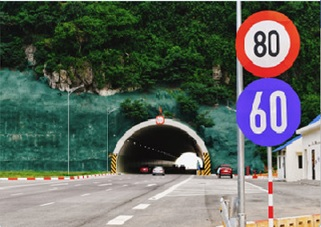

In [4]:
# Đọc ảnh đầu vào
image_path = "/content/drive/MyDrive/Xulyanh/Bien_bao_giaothong.tiff"

# Lấy ảnh từ Drive cất vào biến image
image = cv2.imread(image_path)

# Kiểm tra xem ảnh có bị lỗi đường dẫn hay không
if image is None:
    print("Lỗi: Không thể đọc được ảnh. Bạn kiểm tra lại đường dẫn nhé!")
else:
    print("Ảnh gốc")
    cv2_imshow(image)

Bước 1: Mặt nạ phân vùng biển báo màu đỏ


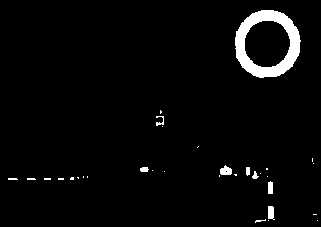

In [5]:
# Bước 1: Chuyển ảnh sang HSV và chọn vùng màu đỏ
# Chuyển đổi không gian màu từ BGR (mặc định) sang HSV để tách màu chính xác hơn
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Khai báo dải màu đỏ thứ nhất (từ H=0 đến H=10)
lower_red_1 = np.array([0, 70, 50])
upper_red_1 = np.array([10, 255, 255])

# Khai báo dải màu đỏ thứ hai (từ H=170 đến H=180)
lower_red_2 = np.array([170, 70, 50])
upper_red_2 = np.array([180, 255, 255])

# Dùng hàm cv2.inRange để tạo mặt nạ (điểm nào thuộc dải màu thì biến thành trắng 255, còn lại thành đen 0)
mask_red_1 = cv2.inRange(hsv_image, lower_red_1, upper_red_1)
mask_red_2 = cv2.inRange(hsv_image, lower_red_2, upper_red_2)

# Cộng 2 mặt nạ lại để lấy được trọn vẹn toàn bộ các sắc độ đỏ
red_mask = mask_red_1 + mask_red_2

print("Bước 1: Mặt nạ phân vùng biển báo màu đỏ")
# Hiển thị kết quả mặt nạ
cv2_imshow(red_mask)

Bước 2: Mặt nạ sau khi khử nhiễu và làm sạch


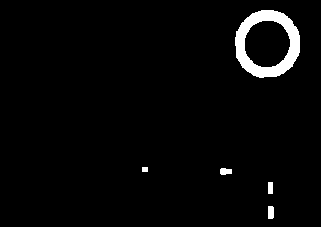

In [6]:
# Bước 2: Làm sạch mặt nạ bằng Xử lý hình thái học (Morphological Operations)
# Tạo phần tử cấu trúc (kernel) là ma trận vuông 5x5
kernel = np.ones((5, 5), np.uint8)

# Phép OPEN (Mở): Xóa các đốm nhiễu trắng nhỏ lấm tấm trên nền đen
binary_image = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel)

# Phép CLOSE (Đóng): Lấp đầy các lỗ hổng màu đen li ti bên trong vùng trắng của biển báo
binary_image = cv2.morphologyEx(binary_image, cv2.MORPH_CLOSE, kernel)

print("Bước 2: Mặt nạ sau khi khử nhiễu và làm sạch")
# Hiển thị kết quả để so sánh với bước 1
cv2_imshow(binary_image)

Bước 3: Đường viền của biển báo


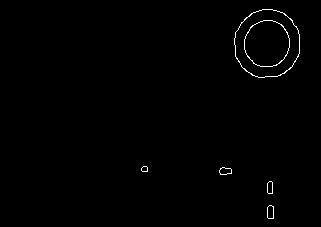

In [7]:
# Bước 3: Tìm cạnh cho hình (Edge Detection)

# Dùng thuật toán Canny tách lấy đường viền từ mặt nạ nhị phân
# 50 (ngưỡng dưới) và 150 (ngưỡng trên) giúp nối liền các nét đứt và loại bỏ nhiễu nhẹ
edge_image = cv2.Canny(binary_image, 50, 150)

print("Bước 3: Đường viền của biển báo")
# Hiển thị kết quả ảnh chỉ còn lại đường viền
cv2_imshow(edge_image)

Bước 4: Vẽ đường viền bao quanh biển báo lên ảnh gốc


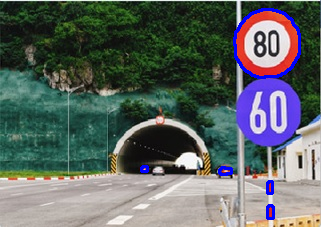

In [8]:
# Bước 4: Tìm và vẽ Contour (Đường viền bao quanh)

# Tìm các contour từ ảnh Canny (edge_image).
# RETR_EXTERNAL: Chỉ lấy các viền ngoài cùng (bỏ qua các chi tiết thừa lọt thỏm bên trong).
# CHAIN_APPROX_SIMPLE: Nén các điểm nằm trên cùng một đường thẳng để tiết kiệm bộ nhớ.
contours, _ = cv2.findContours(edge_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Tạo một bản sao của ảnh gốc để vẽ đè lên (giúp giữ nguyên vẹn biến 'image' ban đầu)
contour_image = image.copy()

# Vẽ tất cả các contour tìm được (-1) lên bản sao bằng màu Xanh dương (255, 0, 0), độ dày nét vẽ là 2 pixel
cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 2)

print("Bước 4: Vẽ đường viền bao quanh biển báo lên ảnh gốc")
# Hiển thị kết quả
cv2_imshow(contour_image)

Bước 5: Khoanh vùng chính xác biển báo lớn nhất


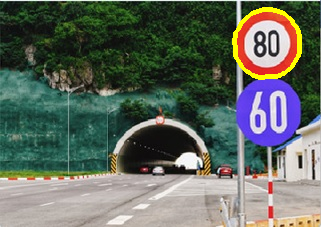

In [9]:
# Bước 5: Xác định contour lớn nhất (Lọc ra biển báo chính)

# Tìm contour có diện tích (contourArea) lớn nhất trong danh sách các contour tìm được.
# Việc này giúp loại bỏ hoàn toàn các viền nhiễu nhỏ vô tình bị lọt vào.
largest_contour = max(contours, key=cv2.contourArea)

# Tạo một bản sao mới từ ảnh gốc
largest_contour_image = image.copy()

# Vẽ contour lớn nhất vừa tìm được lên ảnh.
# Mã màu (0, 255, 255) tương ứng với màu Vàng (Yellow) trong không gian BGR, nét vẽ dày 3 pixel.
cv2.drawContours(largest_contour_image, [largest_contour], -1, (0, 255, 255), 3)

print("Bước 5: Khoanh vùng chính xác biển báo lớn nhất")
# Hiển thị kết quả
cv2_imshow(largest_contour_image)

Bước 6.1: Khung vuông định vị biển báo trên ảnh gốc


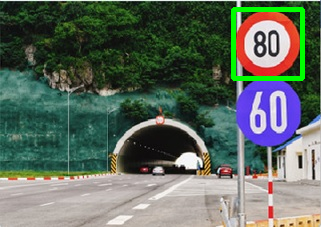


Bước 6.2: Kết quả ảnh đã cắt (Lưu tại: /content/drive/MyDrive/Xulyanh/bien_bao_da_cat.png )


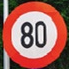

In [10]:
# Bước 6: Vẽ hình vuông (Bounding Box) quanh biển báo và cắt ảnh
# Lấy tọa độ và kích thước khung chữ nhật bao quanh contour lớn nhất
x, y, w, h = cv2.boundingRect(largest_contour)

# Chuyển thành khung hình vuông dựa trên cạnh dài nhất (rất phù hợp cho biển báo tròn)
box_size = max(w, h)

# Xác định tâm của khung
center_x = x + w // 2
center_y = y + h // 2

# Tính tọa độ 4 góc của hình vuông bao quanh tâm
square_x1 = center_x - box_size // 2
square_y1 = center_y - box_size // 2
square_x2 = square_x1 + box_size
square_y2 = square_y1 + box_size

# Giới hạn tọa độ không vượt quá kích thước ảnh gốc (chống lỗi tràn viền)
image_height, image_width = image.shape[:2]
square_x1 = max(0, square_x1)
square_y1 = max(0, square_y1)
square_x2 = min(image_width, square_x2)
square_y2 = min(image_height, square_y2)

# Trích xuất (Crop) vùng ảnh chứa biển báo
cropped_sign = image[square_y1:square_y2, square_x1:square_x2]

# Vẽ khung hình vuông màu xanh lá (0, 255, 0) bao quanh biển báo
result_image = image.copy()
cv2.rectangle(result_image, (square_x1, square_y1), (square_x2, square_y2), (0, 255, 0), 3)

# Lưu ảnh đã cắt thẳng vào thư mục Xulyanh trên Drive
save_path = "/content/drive/MyDrive/Xulyanh/bien_bao_da_cat.png"
cv2.imwrite(save_path, cropped_sign)

# --- Hiển thị kết quả ---
print("Bước 6.1: Khung vuông định vị biển báo trên ảnh gốc")
cv2_imshow(result_image)

print("\nBước 6.2: Kết quả ảnh đã cắt (Lưu tại: {} )".format(save_path))
cv2_imshow(cropped_sign)

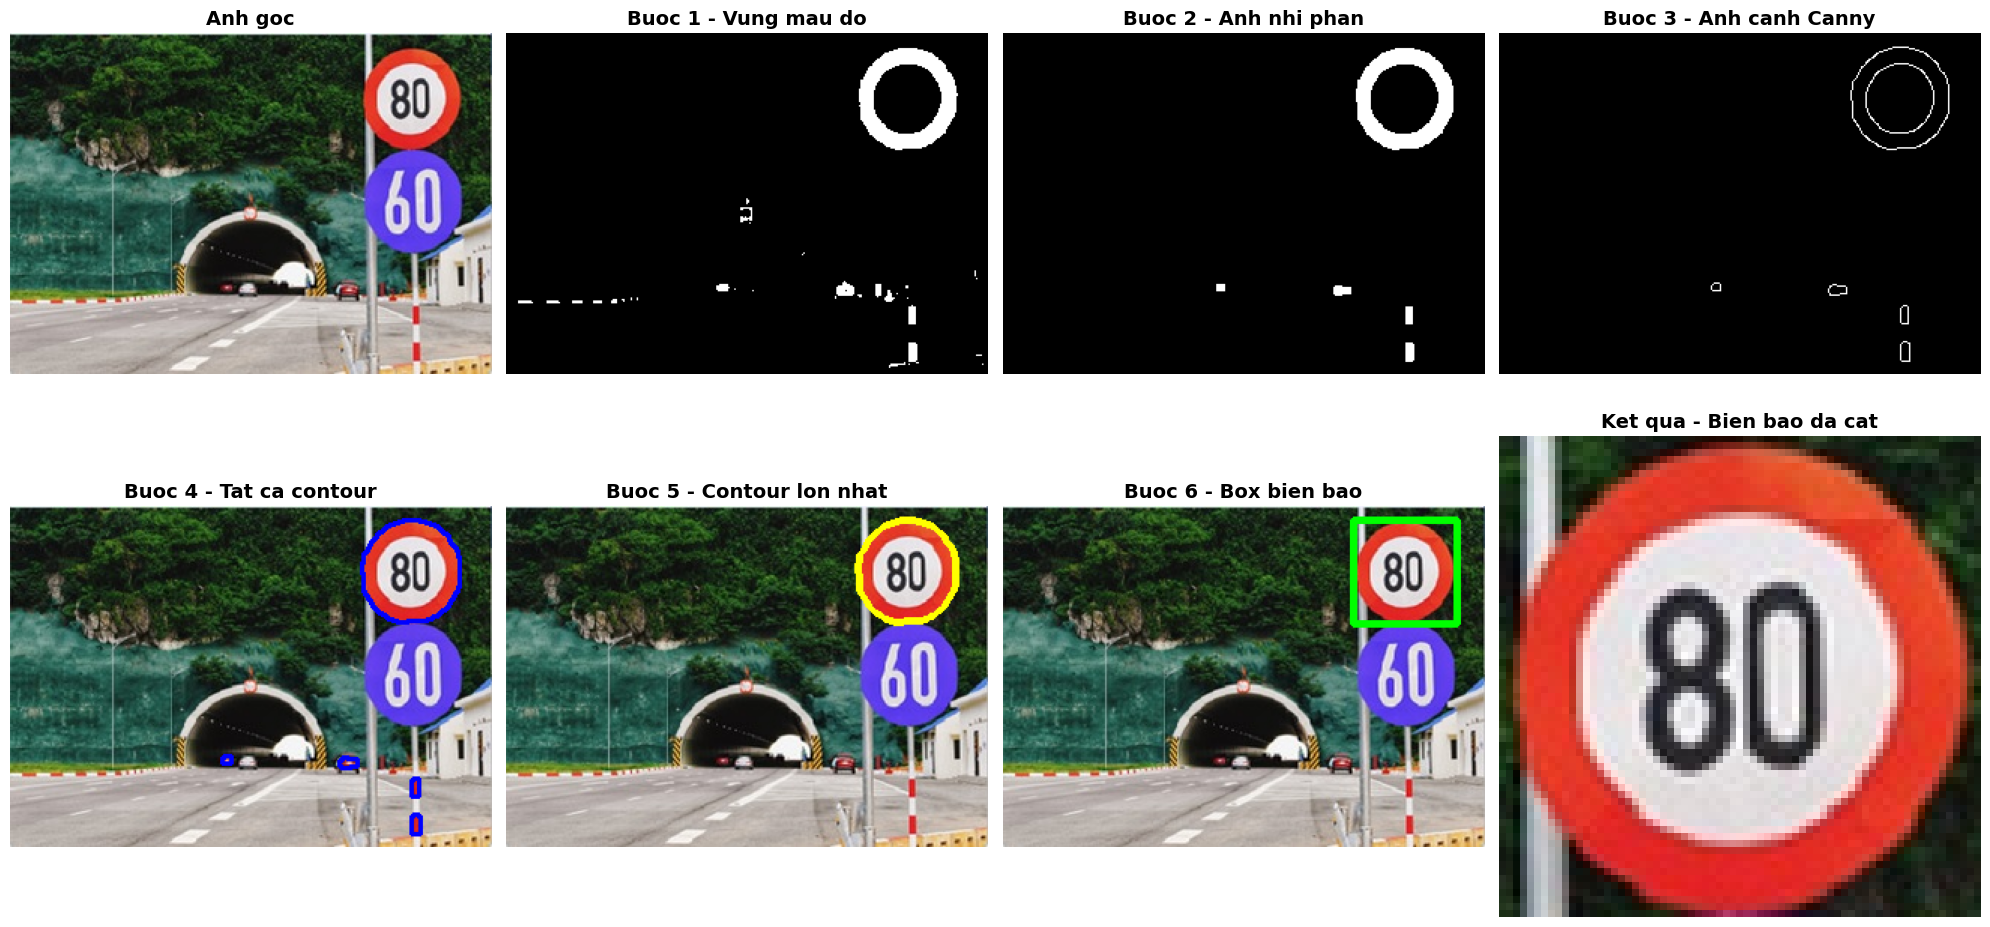

In [11]:
# Sắp xếp và hiển thị 8 ảnh bằng Matplotlib trên Colab
import matplotlib.pyplot as plt

# Hàm phụ trợ chuyển đổi BGR (OpenCV) sang RGB (Matplotlib) để không bị sai màu
def to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Đóng gói danh sách ảnh, tiêu đề và cờ đánh dấu ảnh xám/trắng đen
windows = [
    ("Anh goc", to_rgb(image), False),
    ("Buoc 1 - Vung mau do", red_mask, True),
    ("Buoc 2 - Anh nhi phan", binary_image, True),
    ("Buoc 3 - Anh canh Canny", edge_image, True),
    ("Buoc 4 - Tat ca contour", to_rgb(contour_image), False),
    ("Buoc 5 - Contour lon nhat", to_rgb(largest_contour_image), False),
    ("Buoc 6 - Box bien bao", to_rgb(result_image), False),
    ("Ket qua - Bien bao da cat", to_rgb(cropped_sign), False)
]

# Tạo bảng vẽ kích thước lớn
plt.figure(figsize=(20, 10))

# Lặp qua danh sách và vẽ lên lưới 2 hàng x 4 cột
for i, (name, img, is_gray) in enumerate(windows):
    plt.subplot(2, 4, i + 1)

    if is_gray:
        plt.imshow(img, cmap='gray')  # Hiển thị chuẩn ảnh đen trắng
    else:
        plt.imshow(img)               # Hiển thị ảnh màu

    plt.title(name, fontsize=14, fontweight='bold')
    plt.axis('off')  # Tắt các trục tọa độ cho đẹp

plt.tight_layout()
plt.show()